# Ablation Studies

**Objective**  
Conduct ablation experiments to evaluate how prompt structure and contextual guidance affect LLM performance in predicting Flowmetrics impact stages. This notebook executes two groups of ablations:  
- **Ablation Studies I:** Shuffle stage order in prompts to test whether models infer sequences vs copy the order.  
- **Ablation Studies II:** Vary input context and isolate pipeline phases to measure each phase's contribution.

**Author:** Anonymous  
**Project:** Flowmetrics
**Last updated:** 2025-10-08

---

## Task Overview

This task assesses large language models’ ability to identify which stages of societal research impact are supported by evidence from online platforms. It is framed as a **multi-label classification** problem: each model must determine whether each Flowmetrics stage—**Reach, Engagement, Feedback, Influence, Outcome**—is sufficiently supported by the cumulative platform evidence provided for a pair of research topics.

The stages reflect a flow-based typology of societal impact:
- **Reach** – Initial visibility and dissemination to broad audiences.  
- **Engagement** – Active public or community interaction with research.  
- **Feedback** – Scholarly or expert critique and discussion.  
- **Influence** – Integration of research into authoritative discourse.  
- **Outcome** – Tangible societal or technological effects.

Predictions are benchmarked against cumulative platform evidence derived from Altmetric and CrossRef data. Each model receives structured topic-pair input, normalised platform co-mention scores, and a consistent classification prompt. Evaluation spans three complementary dimensions:

1. **Stage-Level Performance** – Accuracy and F1 for correctly identifying supported stages.  
2. **Sequence-Level Coherence** – Logical ordering of predicted stages relative to the canonical flow (Reach → Engagement → Feedback → Influence → Outcome).  
3. **Cross-Model Agreement** – Consistency and consensus among different model families in stage assignment and progression.

The models evaluated include:
`gpt-3.5-turbo`, `gpt-4o`, `gpt-4o-mini`, `claude-3-7-sonnet-20250219`, `claude-3-5-haiku-20241022`, `DeepSeek-V3`, and `Mixtral 8x22B`.

---

## Table of Contents
1. [Objective](#Objective)
2. [Task Overview](#Task-Overview)
3. [Environment Setup](#Environment-Setup)
4. [Data Loading and Filtering](#Data-Loading-and-Filtering)
5. [Common Utilities](#Common-Utilities)
6. [Prompt Assembly](#Prompt-Assembly)
7. [Model Loading](#Model-Loading)
8. [Model Inference](#Model-Inference)
9. [Metrics](#Metrics)
10. [Ablation Studies I – Stage Order Shuffling](#Ablation-Studies-I-–-Stage-Order-Shuffling)
11. [Ablation Studies II – Context and Pipeline Isolation](#Ablation-Studies-II-–-Context-and-Pipeline-Isolation)
12. [Results Aggregation](#Results-Aggregation)
13. [Visualisations](#Visualisations)
14. [Summary of Ablation Results](#Summary)
15. [Discussion](#Discussion)

## Original Prompt

The experiments in this notebook are based on the original prompt used in [*Paper III (Predicting Research Impact)*](https://www.overleaf.com/read/nydrydmvkjzp#3524fd) to generate LLM predictions. This prompt defines the classification task, provides stage definitions, and specifies the expected output format. All ablation variants are derived from this baseline:

```text
You are an expert in research impact analysis. Your task is to assess the impact of a pair of research topics based on structured evidence of platform co-mentions and shared concepts.

This is a multi-label classification problem. Your goal is to classify all impact stages as either supported or not, based on the strength and relevance of the evidence for each stage.

---

Impact Stages:

- Reach: Broad dissemination of research to general audiences via mass communication platforms (e.g., Twitter, Facebook, Wikipedia).
- Engagement: Active interaction, discussion, or interpretation of research in community-driven forums (e.g., Blogs, Reddit, YouTube).
- Feedback: Scholarly reactions or critical appraisals, often indicating academic interest (e.g., Mendeley).
- Influence: Contribution to discourse in authoritative contexts (e.g., citations via CrossRef, media coverage via News).
- Outcome: Tangible societal or technological effects arising from research (e.g., Policy documents, Patents).

---

Important Notes:

- Platform values are normalised per platform and impact dimension at the topic level (0.0 = no evidence, 1.0 = maximum evidence). For topic pairs, scores are summed (range: 0.0–2.0) to reflect combined impact.
- Classify all impact stages with meaningful or emerging support, considering the total cumulative evidence across platforms, even if individual platform scores are low.
- Err slightly on the side of inclusiveness: if multiple signals exist across platforms, prefer assigning the stage rather than omitting it.
- If cumulative evidence across all platforms for a stage is strictly zero, assign only the "Reach" stage.

---

Now classify this pair:

- Topic 1: {topic_1}  
- Topic 2: {topic_2}  
- Shared Concepts: {shared_concepts}

Platform Co-mention Evidence (normalised values):  
{full_platform_lines}

---

You must begin your output exactly with:

Impact Stages with Sufficient Support: [list of stages]

Followed by:

Impact Summary:
Write a concise (2–4 sentence) summary explaining the evidence for each assigned impact stage. Mention the key platforms and shared concepts that support each stage. Highlight how cumulative evidence across platforms contributed to classification, even if individual signals are small.

## Environment Setup

In [69]:
# Environment Setup
import os, sys, json, random
from pathlib import Path

import numpy as np
import pandas as pd
from rdflib import Graph, URIRef
from rdflib.namespace import RDF, RDFS

ablation_dir = Path(".").resolve()
experiments_dir = ablation_dir.parent
repo_root = experiments_dir.parent
sys.path.append(str(experiments_dir))

from config import models, impact_stages, stage_order

random.seed(42)
np.random.seed(42)

data_dir = repo_root / "data"
outputs_dir = ablation_dir / "outputs"
outputs_dir.mkdir(parents=True, exist_ok=True)

GRAPH_FILE = data_dir / "impact_augmented_kg.ttl"
if not GRAPH_FILE.exists():
    raise FileNotFoundError(f"Missing RDF file: {GRAPH_FILE}")

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

run_cfg = {
    "seed": 42,
    "models": list(models),
    "impact_stages": list(impact_stages),
    "stage_order": list(stage_order),
    "paths": {
        "repo_root": str(repo_root),
        "experiments_dir": str(experiments_dir),
        "ablation_dir": str(ablation_dir),
        "data_dir": str(data_dir),
        "outputs_dir": str(outputs_dir),
        "graph_file": str(GRAPH_FILE),
    },
}
(outputs_dir / "run_config.json").write_text(json.dumps(run_cfg, indent=2), encoding="utf-8")

print("Environment ready")
#print(f"Repo root: {repo_root}")
#print(f"Data dir: {data_dir}")
#print(f"Outputs dir: {outputs_dir}")
print(f"RDF file: {GRAPH_FILE.name}")
print(f"Models: {models}")
print(f"Stages: {impact_stages}")
print(f"Canonical order: {stage_order}")

Environment ready
RDF file: impact_augmented_kg.ttl
Models: ['gpt-3.5-turbo', 'gpt-4o', 'gpt-4o-mini', 'claude-3-7-sonnet-20250219', 'claude-3-5-haiku-20241022', 'open-mixtral-8x22b', 'deepseek-chat']
Stages: ['reach', 'engagement', 'feedback', 'influence', 'outcome']
Canonical order: {'reach': 0, 'engagement': 1, 'feedback': 2, 'influence': 3, 'outcome': 4}


## Data Loading, Filtering, and Stratified Sampling

Load the impact-augmented knowledge graph. This dataset integrates platform co-mention evidence and topic-pair relationships, following the same criteria used in [*Paper III (Predicting Research Impact)*](https://www.overleaf.com/read/nydrydmvkjzp#3524fd).

To keep the ablation experiments computationally feasible while maintaining representativeness, a **publication-grade stratified sample of 200 topic pairs** is drawn from the full KG (771 pairs). Sampling is stratified by **stage diversity**—the number of Flowmetrics stages with non-empty evidence per topic pair—ensuring coverage of both moderately simple (two- to three-stage) and more complex (four-stage) impact patterns.  

This balanced subset preserves the diversity of impact trajectories observed in the full graph while making the large-scale ablation setup (7 models × 10 permutations) computationally manageable.

In [61]:
# Data Loading, Filtering, and Stratified Sampling
from rdflib import Namespace
from typing import Iterable
from collections import Counter
import numpy as np
import pandas as pd

g = Graph()
g.parse(GRAPH_FILE, format="turtle")
print(f"Graph loaded with {len(g):,} triples")

FLOW = Namespace("http://example.org/flowmetrics#")

def compute_true_stages_column(
    df_pairs: pd.DataFrame,
    stages: Iterable[str],
    threshold: float = 0.003,
    colname: str = "true_stages",
) -> pd.DataFrame:
    stages = list(stages)
    def _row_true(row):
        out = set()
        for st in stages:
            ev = row.get(st, [])
            if isinstance(ev, list):
                total = 0.0
                for it in ev:
                    if isinstance(it, (list, tuple)) and len(it) == 2:
                        try:
                            total += float(it[1])
                        except Exception:
                            pass
                if total > threshold:
                    out.add(st)
        return out
    df_pairs[colname] = df_pairs.apply(_row_true, axis=1)
    return df_pairs

def get_label(node):
    label = g.value(node, RDFS.label)
    return str(label) if label else str(node)

def extract_scores(node):
    return [
        (str(platform), float(g.value(node, FLOW.score)))
        for platform in g.objects(node, FLOW.platform)
        if g.value(node, FLOW.score) is not None
    ]

records = []
for pair in g.subjects(RDF.type, FLOW.TopicPair):
    topics = list(g.objects(pair, FLOW.hasTopic))
    if len(topics) != 2:
        continue
    t1, t2 = topics
    t1_label, t2_label = get_label(t1), get_label(t2)
    shared_concepts = [str(c) for c in g.objects(pair, FLOW.hasSharedConcept)]

    def get_impact(prop):
        return [x for node in g.objects(pair, prop) for x in extract_scores(node)]

    records.append({
        "topic_1_id": str(t1),
        "topic_1_name": t1_label,
        "topic_2_id": str(t2),
        "topic_2_name": t2_label,
        "shared_concepts": shared_concepts,
        "reach": get_impact(FLOW.hasReachImpact),
        "engagement": get_impact(FLOW.hasEngagementImpact),
        "feedback": get_impact(FLOW.hasFeedbackImpact),
        "influence": get_impact(FLOW.hasInfluenceImpact),
        "outcome": get_impact(FLOW.hasOutcomeImpact),
    })

df_full = pd.DataFrame(records)
print(f"Extracted topic pairs: {len(df_full):,}")

# Compute ground-truth stages and diversity
df_full = compute_true_stages_column(df_full, impact_stages, threshold=0.003)
df_full["n_stages_true"] = df_full["true_stages"].apply(len)

# ---- Exact-size stratified sampling ----
N_TARGET = 200
strata_counts = df_full["n_stages_true"].value_counts().sort_index()
strata = strata_counts.index.tolist()

if N_TARGET <= 0:
    raise ValueError("N_TARGET must be a positive integer.")

# If target is smaller than number of strata, pick 1 from the largest strata
if N_TARGET < len(strata):
    top_strata = strata_counts.sort_values(ascending=False).index[:N_TARGET]
    alloc = {s: (1 if s in top_strata else 0) for s in strata}
else:
    # Proportional allocation using floor, then distribute residuals by largest fractional remainders
    props = strata_counts / strata_counts.sum()
    exact = props * N_TARGET
    alloc = dict(zip(strata, np.floor(exact).astype(int)))
    residual = N_TARGET - sum(alloc.values())
    if residual > 0:
        remainders = (exact - np.floor(exact)).sort_values(ascending=False)
        for s in remainders.index[:residual]:
            alloc[s] += 1

# Safety: cannot sample more than available in a stratum
for s in list(alloc.keys()):
    alloc[s] = int(min(alloc[s], (df_full["n_stages_true"] == s).sum()))

# If rounding/safety reduced the total, top up from largest strata
while sum(alloc.values()) < N_TARGET:
    for s in strata_counts.sort_values(ascending=False).index:
        avail = (df_full["n_stages_true"] == s).sum()
        if alloc[s] < avail:
            alloc[s] += 1
            if sum(alloc.values()) == N_TARGET:
                break

# Sample
parts = []
rng = 42
for s, n in alloc.items():
    if n <= 0: 
        continue
    pool = df_full[df_full["n_stages_true"] == s]
    parts.append(pool.sample(n=n, random_state=rng))
df = pd.concat(parts, ignore_index=True).sample(frac=1.0, random_state=42).reset_index(drop=True)

print("Publication stratified subset ready.")
print(f"Total sampled: {len(df)} topic pairs (target {N_TARGET})")
print("Allocation by stage diversity:", {int(k): int(v) for k, v in alloc.items()})

print("============ Stratified Subset Summary ============")
print(f"Total topic pairs: {len(df)}")
print("Stage diversity distribution:")
display(df["n_stages_true"].value_counts().sort_index().to_frame("count"))

print(f"\nAverage number of supported stages per pair: {df['n_stages_true'].mean():.2f}")

# Stage coverage
from collections import Counter
stage_counts = Counter([st for s in df["true_stages"] for st in s])
stage_df = pd.DataFrame.from_dict(stage_counts, orient="index", columns=["count"]).reindex(impact_stages)
stage_df["proportion"] = stage_df["count"] / stage_df["count"].sum()
print("\nStage-level coverage:")
display(stage_df)

# Representative examples per diversity level
print("\nExample topic pairs per stage-diversity level:")
for d in sorted(df["n_stages_true"].unique()):
    examples = df[df["n_stages_true"] == d].head(2)
    for _, row in examples.iterrows():
        print(f"  • {row['topic_1_name']} ↔ {row['topic_2_name']} ({len(row['true_stages'])} stages: {', '.join(row['true_stages'])})")

Graph loaded with 33,897 triples
Extracted topic pairs: 771
Publication stratified subset ready.
Total sampled: 200 topic pairs (target 200)
Allocation by stage diversity: {0: 14, 1: 20, 2: 21, 3: 34, 4: 111}
============ Stratified Subset Summary ============
Total topic pairs: 200
Stage diversity distribution:


,count
n_stages_true,
0,14
1,20
2,21
3,34
4,111



Average number of supported stages per pair: 3.04

Stage-level coverage:


,count,proportion
reach,181.0,0.297697
engagement,122.0,0.200658
feedback,NaN,NaN
influence,155.0,0.254934
outcome,150.0,0.246711



Example topic pairs per stage-diversity level:
  • audio ↔ automation (0 stages: )
  • prediction modes ↔ facial expression (0 stages: )
  • viewpoint ↔ software frameworks (1 stages: reach)
  • virtual spaces ↔ audio (1 stages: reach)
  • search engines ↔ knowledge base (2 stages: influence, outcome)
  • automation ↔ vehicles (2 stages: reach, outcome)
  • reference image ↔ facial images (3 stages: reach, influence, outcome)
  • encoder-decoder ↔ computational efficiency (3 stages: reach, influence, outcome)
  • user information ↔ integrated data (4 stages: reach, influence, engagement, outcome)
  • adaptive algorithms ↔ reference image (4 stages: reach, influence, engagement, outcome)


## Common Utilities
Helper functions for prompt generation, deterministic shuffling, configuration management, and metrics scaffolding.

In [62]:
# Common Utilities
from collections import defaultdict
STAGES_CANON = list(impact_stages)
STAGE_LC2CAN = {s.lower(): s for s in impact_stages}

def build_shared_concepts_str(concepts, max_terms=None) -> str:
    if not concepts:
        return "(none)"
    items = [str(x) for x in concepts]
    return ", ".join(items[:max_terms]) + (" …" if max_terms and len(items) > max_terms else "")

def assemble_platform_lines_for_pair_flat(row, digits: int = 3) -> str:
    """Flatten evidence across all stages into a single comma-separated list."""
    totals = defaultdict(float)
    for stage in impact_stages:
        entries = row.get(stage, [])
        if not isinstance(entries, list):
            continue
        for item in entries:
            if isinstance(item, (list, tuple)) and len(item) == 2:
                plat, val = item
                try:
                    totals[str(plat)] += float(val)
                except Exception:
                    pass
    # Paper convention: pair score range 0.0–2.0 (cap)
    items = sorted(totals.items(), key=lambda kv: kv[1], reverse=True)
    return ", ".join(f"{p}: {min(v, 2.0):.{digits}f}" for p, v in items)

print("Common utilities ready.")

Common utilities ready.


## Prompt Assembly

This section builds the classification prompt for each research topic pair using data extracted from the *impact-augmented knowledge graph*.

Each prompt follows the original Flowmetrics instruction template, embedding:
- **Topic 1 and Topic 2 labels**
- **Shared concepts**
- **Platform co-mention evidence**, normalised per platform and summed at the topic-pair level

The prompt defines a **multi-label classification** task in which the model determines which of the five Flowmetrics stages—Reach, Engagement, Feedback, Influence, and Outcome—are supported by cumulative online evidence.

This function (`apply_prompt_template`) is reused across all ablation experiments, ensuring a consistent baseline. Variants introduced later in the notebook (e.g., shuffled stage order, reduced context) modify only specific sections of this base prompt.

In [63]:
# Prompt Assembly
import textwrap

BASE_PROMPT_TEMPLATE = textwrap.dedent("""
You are an expert in research impact analysis. Your task is to assess the impact of a pair of research topics based on structured evidence of platform co-mentions and shared concepts.

This is a multi-label classification problem. Your goal is to classify all impact stages as either supported or not, based on the strength and relevance of the evidence for each stage.

---

Impact Stages:

- Reach: Broad dissemination of research to general audiences via mass communication platforms (e.g., Twitter, Facebook, Wikipedia).
- Engagement: Active interaction, discussion, or interpretation of research in community-driven forums (e.g., Blogs, Reddit, YouTube).
- Feedback: Scholarly reactions or critical appraisals, often indicating academic interest (e.g., Mendeley).
- Influence: Contribution to discourse in authoritative contexts (e.g., citations via CrossRef, media coverage via News).
- Outcome: Tangible societal or technological effects arising from research (e.g., Policy documents, Patents).

---

Important Notes:

- Platform values are normalised per platform and impact dimension at the topic level (0.0 = no evidence, 1.0 = maximum evidence). For topic pairs, scores are summed (range: 0.0–2.0) to reflect combined impact.
- Classify all impact stages with meaningful or emerging support, considering the total cumulative evidence across platforms, even if individual platform scores are low.
- Err slightly on the side of inclusiveness: if multiple signals exist across platforms, prefer assigning the stage rather than omitting it.
- If cumulative evidence across all platforms for a stage is strictly zero, assign only the "Reach" stage.

---

Now classify this pair:

- Topic 1: {topic_1}
- Topic 2: {topic_2}
- Shared Concepts: {shared_concepts}

Platform Co-mention Evidence (normalised values):
{full_platform_lines}

---

You must begin your output exactly with:

Impact Stages with Sufficient Support: [list of stages]

Followed by:

Impact Summary:
Write a concise (2–4 sentence) summary explaining the evidence for each assigned impact stage. Mention the key platforms and shared concepts that support each stage. Highlight how cumulative evidence across platforms contributed to classification, even if individual signals are small.
""").strip()

def apply_prompt_template(row: pd.Series, prompt_template: str = BASE_PROMPT_TEMPLATE) -> str:
    return prompt_template.format(
        topic_1=row["topic_1_name"],
        topic_2=row["topic_2_name"],
        shared_concepts=build_shared_concepts_str(row.get("shared_concepts", [])),
        full_platform_lines=assemble_platform_lines_for_pair_flat(row),
    )

## Model Loading

This section initialises and manages all supported LLMs using a unified, LangChain-compatible interface.

It supports both **local Hugging Face models** and **API-based providers** (OpenAI, Anthropic, DeepSeek, and Mistral). Each model is loaded through the function `load_model(model_name, temperature, max_tokens)`, which returns an object compatible with LangChain’s `.predict()` or `.invoke()` methods.

**Supported models**
- OpenAI: `gpt-3.5-turbo`, `gpt-4o`, `gpt-4o-mini`  
- Anthropic: `claude-3-7-sonnet-20250219`, `claude-3-5-haiku-20241022`  
- DeepSeek: `DeepSeek-V3`, `deepseek-reasoner`, `deepseek-chat`  
- Mistral: `Mixtral 8x22B`, `open-mixtral-8x7b`  
- Local: `DeepSeek-R1-Distill-Qwen-1.5B`, `Llama-3.2-1B`, `Mistral-7B-Instruct-v0.1`

Each API model requires its respective key to be available in the environment (`OPENAI_API_KEY`, `ANTHROPIC_API_KEY`, `DEEPSEEK_API_KEY`, `MISTRAL_API_KEY`). Local models are loaded from the directory specified in `MODEL_PATH`.

This modular loading layer ensures reproducibility across ablation studies while keeping inference parameters consistent.

In [65]:
# Model Loading
from pathlib import Path
import os

def load_model(model_name: str, temperature: float = 0.1, max_tokens: int = 1024):
    if model_name in {"gpt-3.5-turbo", "gpt-4o", "gpt-4o-mini"}:
        from langchain.chat_models import ChatOpenAI
        api_key = OPENAI_API_KEY
        if not api_key:
            raise EnvironmentError("OPENAI_API_KEY not set.")
        return ChatOpenAI(model_name=model_name, temperature=temperature, max_tokens=max_tokens, openai_api_key=api_key)

    if model_name in {"claude-3-7-sonnet-20250219", "claude-3-5-haiku-20241022"}:
        from langchain_anthropic import ChatAnthropic
        api_key = ANTHROPIC_API_KEY
        if not api_key:
            raise EnvironmentError("ANTHROPIC_API_KEY not set.")
        return ChatAnthropic(model_name=model_name, temperature=temperature, max_tokens=max_tokens, anthropic_api_key=api_key)

    if model_name in {"DeepSeek-V3", "deepseek-chat", "deepseek-reasoner"}:
        from langchain.chat_models import ChatOpenAI
        api_key = DEEPSEEK_API_KEY
        if not api_key:
            raise EnvironmentError("DEEPSEEK_API_KEY not set.")
        return ChatOpenAI(
            model_name="deepseek-chat",
            temperature=temperature,
            max_tokens=max_tokens,
            openai_api_key=api_key,
            openai_api_base="https://api.deepseek.com/v1"
        )

    if model_name in {"Mixtral 8x22B", "open-mixtral-8x22b", "open-mixtral-8x7b"}:
        from langchain_mistralai import ChatMistralAI
        api_key = MISTRAL_API_KEY
        if not api_key:
            raise EnvironmentError("MISTRAL_API_KEY not set.")
        resolved = "open-mixtral-8x22b" if "22" in model_name else "open-mixtral-8x7b"
        return ChatMistralAI(model_name=resolved, temperature=temperature, max_tokens=max_tokens, mistral_api_key=api_key)

    if model_name.startswith("local:"):
        from transformers import pipeline as hf_pipeline
        from langchain.llms import HuggingFacePipeline
        model_dir = Path(os.getenv("MODEL_PATH", "")) / model_name.split("local:", 1)[-1]
        if not model_dir.exists():
            raise FileNotFoundError(f"Local model not found: {model_dir}")
        gen = hf_pipeline("text-generation", model=str(model_dir), max_new_tokens=max_tokens)
        return HuggingFacePipeline(pipeline=gen)

    raise ValueError(f"Unsupported model: {model_name}")

## Model Inference and Response Parsing

This section runs the formatted prompts against each model and extracts structured outputs.

The inference workflow proceeds as follows:
1. **Prompt construction** via `apply_prompt_template()` or its ablated variants  
2. **Model call** using `generate_response(model_name, prompt)`  
3. **Response parsing** to extract:
   - `predicted_stages_[model]`: list of supported impact stages  
   - `impact_summary_[model]`: 2–4 sentence narrative summary  
   - `raw_response_[model]`: full unprocessed model output  

The extraction logic identifies the line beginning with `Impact Stages with Sufficient Support: [list of stages]` and parses the subsequent text following `Impact Summary:`.

These outputs form the foundation for evaluating model accuracy, sequence coherence, and robustness under the ablation conditions.

In [66]:
# Model Inference & Parsing
import re, time
from httpx import HTTPStatusError
from langchain import LLMChain, PromptTemplate

HEADER_RE = re.compile(
    r"(?:Impact Stages with Sufficient Support|Impact Stages|Supported Stages)\s*:\s*(?:\[(?P<inside1>[^\]]*)\]|(?P<inside2>.+?))(?:\n{2,}|\r?\n|\Z)",
    re.I | re.S,
)
TOKEN_SPLIT = re.compile(r"[,\n;•·\-–—]+")
STAGE_LC2CAN = {s.lower(): s for s in impact_stages}
SUMMARY_RE = re.compile(r"Impact Summary\s*:\s*(.*)$", re.I | re.S)

def robust_parse_supported_stages(text: str) -> list[str]:
    if not text:
        return []
    m = HEADER_RE.search(text)
    if not m:
        return []
    inside = m.group("inside1") or m.group("inside2") or ""
    parts = [t.strip(" .:|/\\()[]{}\"'").lower() for t in TOKEN_SPLIT.split(inside) if t.strip()]
    out, seen = [], set()
    for p in parts:
        s = STAGE_LC2CAN.get(p)
        if s and s not in seen:
            seen.add(s); out.append(s)
    return out

def parse_impact_summary(raw_text: str) -> str:
    m = SUMMARY_RE.search(raw_text or "")
    return m.group(1).strip() if m else ""

def generate_response(model_name: str, prompt: str, *, temperature: float = 0.1, max_tokens: int = 4096) -> str:
    """Call model with retry handling for rate limits (HTTP 429)."""
    model = load_model(model_name, temperature=temperature, max_tokens=max_tokens)
    chain = LLMChain(llm=model, prompt=PromptTemplate(template="{prompt}", input_variables=["prompt"]))
    for attempt in range(3):  # up to 3 retries
        try:
            return chain.run({"prompt": prompt})
        except HTTPStatusError as e:
            if e.response.status_code == 429:
                wait = 10 * (attempt + 1)
                print(f"Rate limit hit ({model_name}), retrying in {wait}s...")
                time.sleep(wait)
            else:
                raise
        except Exception as e:
            print(f"Unexpected error ({model_name}): {e}")
            if attempt < 2:
                wait = 5 * (attempt + 1)
                print(f"Retrying in {wait}s...")
                time.sleep(wait)
            else:
                raise
    raise RuntimeError(f"Failed after 3 attempts for {model_name}")

def iterate_and_generate_responses(
    topic_pairs_df: pd.DataFrame,
    model_name: str,
    *,
    prompt_fn,
    temperature: float = 0.1,
    max_tokens: int = 1024,
) -> pd.DataFrame:
    pred_col = f"predicted_stages_{model_name}"
    summ_col = f"impact_summary_{model_name}"
    raw_col  = f"raw_response_{model_name}"

    raws, preds, sums = [], [], []
    for _, row in topic_pairs_df.iterrows():
        prompt = prompt_fn(row)
        raw = generate_response(model_name, prompt, temperature=temperature, max_tokens=max_tokens).strip()
        raws.append(raw)
        preds.append(robust_parse_supported_stages(raw))
        sums.append(parse_impact_summary(raw))

    out = topic_pairs_df.copy()
    out[pred_col], out[summ_col], out[raw_col] = preds, sums, raws
    #print(f"[{model_name}] empty prediction rate: {out[pred_col].apply(lambda x: not x).mean():.3f}")
    return out

## Metrics — Stage-Level Performance (Ablation Setup)

This section computes **stage-level performance metrics** for each model under different ablation settings.

Because no manually annotated gold standard exists, a **proxy ground truth** is derived from the impact-augmented knowledge graph:  
a stage is considered *present* if its cumulative evidence score across all platforms exceeds a fixed threshold (**0.003**, as in the main paper).

Each model’s predicted stages (`predicted_stages_<model>`) are compared to these proxy labels using standard **multi-label classification metrics**:

- **Precision** – proportion of predicted stages that are truly supported  
- **Recall** – proportion of true stages correctly predicted  
- **F1-score** – harmonic mean of precision and recall  
- **Accuracy** – stage-wise classification accuracy 

These metrics are calculated for:
- Each **impact stage** individually, and  
- Each **model configuration** (baseline, shuffled, minimal context, etc.)

The goal here is to **record raw metric values and intermediate tables** for subsequent aggregation.

In [67]:
# Metrics — Stage-Level
from typing import Iterable, Tuple, Dict, List
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, hamming_loss

def _to_one_hot(labels: Iterable[str], stages: List[str]) -> List[int]:
    ls = {x.lower() for x in (labels or [])}
    return [int(st.lower() in ls) for st in stages]

def evaluate_stage_level_one_model(
    df_pairs: pd.DataFrame,
    model_name: str,
    stages: Iterable[str],
    true_col: str = "true_stages",
) -> Tuple[pd.DataFrame, Dict[str, float]]:
    stages = list(stages)
    y_true_sets = df_pairs[true_col].apply(lambda s: {x.lower() for x in (s or set())})

    pred_col = f"predicted_stages_{model_name}"
    if pred_col in df_pairs.columns:
        y_pred_sets = df_pairs[pred_col].apply(
            lambda lst: {x.lower() for x in (lst if isinstance(lst, (list, tuple)) else []) if isinstance(x, str)}
        )
    else:
        y_pred_sets = pd.Series([set() for _ in range(len(df_pairs))], index=df_pairs.index)

    rows = {}
    for st in stages:
        k = st.lower()
        yt = y_true_sets.apply(lambda s: k in s).astype(int)
        yp = y_pred_sets.apply(lambda s: k in s).astype(int)
        rows[st] = {
            "Precision": precision_score(yt, yp, zero_division=0),
            "Recall":    recall_score(yt, yp, zero_division=0),
            "F1":        f1_score(yt, yp, zero_division=0),
            "Accuracy":  accuracy_score(yt, yp),
        }
    per_stage_df = pd.DataFrame(rows).T.loc[stages]

    y_true_bin = np.asarray([_to_one_hot(s or set(), stages) for s in df_pairs[true_col]])
    y_pred_bin = np.asarray([
        _to_one_hot(set(x if isinstance(x, (list, tuple)) else []), stages)
        for x in df_pairs.get(pred_col, [[]] * len(df_pairs))
    ])
    ham = hamming_loss(y_true_bin, y_pred_bin)

    global_dict = {
        "model": model_name,
        "Precision": round(per_stage_df["Precision"].mean(), 3),
        "Recall":    round(per_stage_df["Recall"].mean(), 3),
        "F1 Score":  round(per_stage_df["F1"].mean(), 3),
        "Accuracy":  round(per_stage_df["Accuracy"].mean(), 3),
        "Hamming Loss": round(ham, 3),
        "n_pairs": len(df_pairs),
    }
    return per_stage_df, global_dict

def evaluate_stage_level(
    df_pairs: pd.DataFrame,
    models_list: Iterable[str],
    stages: Iterable[str],
    true_col: str = "true_stages",
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    per_stage_all, global_all = [], []
    for m in models_list:
        per_stage_df, global_dict = evaluate_stage_level_one_model(df_pairs, m, stages, true_col=true_col)
        per_stage_df = per_stage_df.reset_index().rename(columns={"index": "stage"})
        per_stage_df.insert(0, "model", m)
        per_stage_all.append(per_stage_df)
        global_all.append(global_dict)
    return (
        pd.concat(per_stage_all, ignore_index=True) if per_stage_all else pd.DataFrame(),
        pd.DataFrame(global_all).sort_values("model") if global_all else pd.DataFrame(),
    )

## Ablation Studies I – Stage Order Shuffling
**Aim**: Test whether models infer sequence structure or copy the order presented in prompts. We will generate prompts with multiple stage permutations and compare sequence metrics across permutations.

In [68]:
# Ablation Studies I — Stage Order Shuffling (Stage-Level; canonical + adversarial + random)
from typing import List, Tuple
import numpy as np, pandas as pd, re, json
from tqdm import tqdm

RESULTS_DIR_I = outputs_dir / "ablation_i_shuffle"
RESULTS_DIR_I.mkdir(parents=True, exist_ok=True)

# Config
SEED_BASE = 2025
TEMPERATURE = 0.1
MAX_TOKENS = 4096
NAMES_ONLY = False
UNORDERED_NOTE = True
RUN_MODELS = models       # e.g. ["gpt-4o", "gpt-4o-mini"]
N_RANDOM = 5              # number of additional random permutations
SAMPLE_N = None           # number of topic pairs to process (None = all)
CHKP_FILE = RESULTS_DIR_I / "processed_pairs.json"

# Stage definitions
STAGE_DEFS = {
    "Reach": "- Reach: Broad dissemination of research to general audiences via mass communication platforms (e.g., Twitter, Facebook, Wikipedia).",
    "Engagement": "- Engagement: Active interaction, discussion, or interpretation of research in community-driven forums (e.g., Blogs, Reddit, YouTube).",
    "Feedback": "- Feedback: Scholarly reactions or critical appraisals, often indicating academic interest (e.g., Mendeley).",
    "Influence": "- Influence: Contribution to discourse in authoritative contexts (e.g., citations via CrossRef, media coverage via News).",
    "Outcome": "- Outcome: Tangible societal or technological effects arising from research (e.g., Policy documents, Patents).",
}
_IMPACT_RE = re.compile(r"(Impact Stages:\s*\n)(.*?)(\n---)", flags=re.DOTALL | re.IGNORECASE)

def _stage_block(order: List[str], names_only=False, unordered_note=True) -> str:
    lines = [f"- {s}" for s in order] if names_only else [STAGE_DEFS[s.capitalize()] for s in order]
    note = "\n\nNote: Stages are unordered; do not assume this list implies a sequence." if unordered_note else ""
    return "\n".join(lines) + note

def inject_stage_order_into_template(base_template: str, order: List[str], names_only=False, unordered_note=True) -> str:
    block = f"Impact Stages:\n\n{_stage_block(order, names_only, unordered_note)}\n\n---"
    return _IMPACT_RE.sub(lambda m: block, base_template)

# Permutation generation
ADVERSARIAL = [
    ("perm_rev", ["Outcome","Influence","Feedback","Engagement","Reach"]),
    ("perm_eng_first", ["Engagement","Reach","Feedback","Influence","Outcome"]),
    ("perm_inf_first", ["Influence","Reach","Engagement","Feedback","Outcome"]),
    ("perm_reach_last", ["Engagement","Feedback","Influence","Outcome","Reach"]),
]
def make_permutations(stage_list, k_random=4, seed=2025):
    rng = np.random.RandomState(seed)
    out = [("perm_0_canonical", stage_list[:])] + ADVERSARIAL[:]
    seen = {tuple(p) for _, p in out}
    i = 0
    while i < k_random:
        s = stage_list[:]; rng.shuffle(s); t = tuple(s)
        if t not in seen:
            out.append((f"perm_rand_{i}", s)); seen.add(t); i += 1
    return out

# Load progress
processed_pairs = set()
if CHKP_FILE.exists():
    processed_pairs = set(json.loads(CHKP_FILE.read_text()))
    print(f"Resuming run — {len(processed_pairs)} pairs already processed.")

# Prepare data
df = compute_true_stages_column(df, STAGES_CANON, threshold=0.003)

if SAMPLE_N is not None:
    df = df.sample(n=min(SAMPLE_N, len(df)), random_state=42).reset_index(drop=True)
    print(f"Running on {len(df)} topic pair(s) (SAMPLE_N={SAMPLE_N})")
else:
    print(f"Running on all {len(df)} topic pairs")

perm_orders = make_permutations(list(stage_order), k_random=N_RANDOM, seed=SEED_BASE)
perm_orders = [(n, [s.capitalize() for s in order]) for n, order in perm_orders]
print(f"Generated {len(perm_orders)} stage permutations:")
for name, order in perm_orders:
    print(f" - {name}: {order}")

# === Iterate over permutations (outer loop) ===
all_stage_per_stage, all_stage_global = [], []
N_LIMIT = 10

for perm_name, order in perm_orders:
    print(f"\n=== Running permutation: {perm_name} | order={order} ===")
    templ = inject_stage_order_into_template(
        BASE_PROMPT_TEMPLATE,
        order,
        names_only=NAMES_ONLY,
        unordered_note=UNORDERED_NOTE
    )

    for idx, row in tqdm(df.iterrows(), total=len(df), desc=f"{perm_name}"):
        if idx >= N_LIMIT:
            print(f"\n[Break] Stopping early after {N_LIMIT} topic pairs (temporary test).")
            break
        
        pair_id = f"{row['topic_1_id']}::{row['topic_2_id']}"
        if pair_id in processed_pairs:
            continue

        print(f">>> Processing pair {idx+1}/{len(df)}: {row['topic_1_name']} ↔ {row['topic_2_name']}")

        df_single = pd.DataFrame([row])
        df_work = df_single.copy()
        models_present = []

        for m in RUN_MODELS:
            df_work = iterate_and_generate_responses(
                df_work,
                m,
                prompt_fn=lambda row, _templ=templ: apply_prompt_template(row, prompt_template=_templ),
                temperature=TEMPERATURE,
                max_tokens=MAX_TOKENS
            )
            if f"predicted_stages_{m}" in df_work.columns:
                models_present.append(m)

        if not models_present:
            continue

        per_stage, global_summary = evaluate_stage_level(
            df_work, models_present, STAGES_CANON, true_col="true_stages"
        )
        per_stage["condition"] = f"I:{perm_name}"
        per_stage["presented_order"] = [tuple(order)] * len(per_stage)
        global_summary["condition"] = f"I:{perm_name}"

        all_stage_per_stage.append(per_stage)
        all_stage_global.append(global_summary)

        processed_pairs.add(pair_id)
        if len(processed_pairs) % 5 == 0:
            CHKP_FILE.write_text(json.dumps(list(processed_pairs), indent=2))

    print(f"✓ Finished permutation {perm_name} ({len(processed_pairs)}/{len(df)} pairs processed so far)")

# Save incrementally aggregated results
if all_stage_per_stage:
    abl1_stage_per_stage = pd.concat(all_stage_per_stage, ignore_index=True)
    abl1_stage_global = pd.concat(all_stage_global, ignore_index=True)
    abl1_stage_per_stage.to_csv(RESULTS_DIR_I / "ALL_stage_level_per_stage.csv", mode="a", header=not (RESULTS_DIR_I / "ALL_stage_level_per_stage.csv").exists(), index=False)
    abl1_stage_global.to_csv(RESULTS_DIR_I / "ALL_stage_level_global.csv", mode="a", header=not (RESULTS_DIR_I / "ALL_stage_level_global.csv").exists(), index=False)
    CHKP_FILE.write_text(json.dumps(list(processed_pairs), indent=2))
    print(f"\nSaved results for {len(processed_pairs)} processed pairs total.")
else:
    print("No new results produced — all pairs may already be processed.")

Resuming run — 5 pairs already processed.
Running on all 200 topic pairs
Generated 10 stage permutations:
 - perm_0_canonical: ['Reach', 'Engagement', 'Feedback', 'Influence', 'Outcome']
 - perm_rev: ['Outcome', 'Influence', 'Feedback', 'Engagement', 'Reach']
 - perm_eng_first: ['Engagement', 'Reach', 'Feedback', 'Influence', 'Outcome']
 - perm_inf_first: ['Influence', 'Reach', 'Engagement', 'Feedback', 'Outcome']
 - perm_reach_last: ['Engagement', 'Feedback', 'Influence', 'Outcome', 'Reach']
 - perm_rand_0: ['Engagement', 'Influence', 'Reach', 'Outcome', 'Feedback']
 - perm_rand_1: ['Engagement', 'Feedback', 'Reach', 'Outcome', 'Influence']
 - perm_rand_2: ['Influence', 'Outcome', 'Feedback', 'Engagement', 'Reach']
 - perm_rand_3: ['Influence', 'Feedback', 'Outcome', 'Reach', 'Engagement']
 - perm_rand_4: ['Feedback', 'Engagement', 'Influence', 'Reach', 'Outcome']

=== Running permutation: perm_0_canonical | order=['Reach', 'Engagement', 'Feedback', 'Influence', 'Outcome'] ===


perm_0_canonical:   0%|                                                                                                                                 | 0/200 [00:00<?, ?it/s]

>>> Processing pair 1/200: user information ↔ integrated data


perm_0_canonical:   0%|▌                                                                                                                      | 1/200 [00:27<1:32:08, 27.78s/it]

>>> Processing pair 2/200: viewpoint ↔ software frameworks


...


[Break] Stopping early after 10 topic pairs (temporary test).
✓ Finished permutation perm_rand_2 (15/200 pairs processed so far)

=== Running permutation: perm_rand_3 | order=['Influence', 'Feedback', 'Outcome', 'Reach', 'Engagement'] ===


perm_rand_3:   5%|██████                                                                                                                    | 10/200 [00:00<00:00, 20929.66it/s]



[Break] Stopping early after 10 topic pairs (temporary test).
✓ Finished permutation perm_rand_3 (15/200 pairs processed so far)

=== Running permutation: perm_rand_4 | order=['Feedback', 'Engagement', 'Influence', 'Reach', 'Outcome'] ===


perm_rand_4:   5%|██████▏                                                                                                                    | 10/200 [00:00<00:00, 9586.98it/s]


[Break] Stopping early after 10 topic pairs (temporary test).
✓ Finished permutation perm_rand_4 (15/200 pairs processed so far)

Saved results for 15 processed pairs total.


## Ablation Studies II – Context and Pipeline Isolation
**Aim**: Vary input context and isolate pipeline phases to measure their contribution. We will implement a minimal-input setting and progressively add guidance. We will also emulate phase isolation by controlling which evidence is passed in.

In [28]:
# Ablation Studies II — Context and Pipeline Isolation
import re
import numpy as np
import pandas as pd
from typing import List, Dict, Callable
from collections import defaultdict

RESULTS_DIR_II = outputs_dir / "ablation_ii_context"
RESULTS_DIR_II.mkdir(parents=True, exist_ok=True)

TEMPERATURE = 0.1
MAX_TOKENS = 4096
RUN_MODELS = models
SAMPLE_N = None

def assemble_platform_lines_for_pair_filtered(row, include_stages: List[str] | None, digits: int = 3, *, flatten: bool = True) -> str:
    if flatten:
        keep = {s.lower() for s in include_stages} if include_stages else None
        totals = defaultdict(float)
        for stage in impact_stages:
            if keep and stage.lower() not in keep:
                continue
            entries = row.get(stage, [])
            if not isinstance(entries, list):
                continue
            for it in entries:
                if isinstance(it, (list, tuple)) and len(it) == 2:
                    p, v = it
                    try:
                        totals[str(p)] += float(v)
                    except Exception:
                        pass
        items = sorted(totals.items(), key=lambda kv: kv[1], reverse=True)
        return ", ".join(f"{p}: {min(v, 2.0):.{digits}f}" for p, v in items) if items else "- (no evidence)"
    else:
        keep = {s.lower() for s in include_stages} if include_stages else None
        lines = []
        for stage in impact_stages:
            if keep and stage.lower() not in keep:
                continue
            entries = row.get(stage, [])
            if not isinstance(entries, list):
                continue
            parts = []
            for it in entries:
                if isinstance(it, (list, tuple)) and len(it) == 2:
                    p, v = it
                    try:
                        parts.append(f"{p}: {float(v):.{digits}f}")
                    except Exception:
                        pass
            if parts:
                lines.append(", ".join(parts))
        return "\n".join(lines) if lines else "- (no evidence)"

MINIMAL_PROMPT = """
You are an expert in research impact analysis.
Classify which impact stages apply to the topic pair below.

Now classify this pair:
- Topic 1: {topic_1}
- Topic 2: {topic_2}
- Shared Concepts: {shared_concepts}

Output format:
Impact Stages with Sufficient Support: [list of stages]
Impact Summary: brief justification.
""".strip()

NAMES_ONLY_PROMPT = """
You are an expert in research impact analysis.
Classify which impact stages apply to the topic pair below.

Impact Stages:
- Reach
- Engagement
- Feedback
- Influence
- Outcome

Now classify this pair:
- Topic 1: {topic_1}
- Topic 2: {topic_2}
- Shared Concepts: {shared_concepts}

Platform Co-mention Evidence:
{platform_evidence}

Output format:
Impact Stages with Sufficient Support: [list of stages]
Impact Summary: brief justification.
""".strip()

FULL_PROMPT = BASE_PROMPT_TEMPLATE

def prompt_minimal(row: pd.Series) -> str:
    return MINIMAL_PROMPT.format(
        topic_1=row["topic_1_name"],
        topic_2=row["topic_2_name"],
        shared_concepts=build_shared_concepts_str(row.get("shared_concepts", [])),
    )

def prompt_names_only(row: pd.Series, include_stages: List[str] | None, *, flatten=True) -> str:
    ev = assemble_platform_lines_for_pair_filtered(row, include_stages=include_stages, flatten=flatten)
    return NAMES_ONLY_PROMPT.format(
        topic_1=row["topic_1_name"],
        topic_2=row["topic_2_name"],
        shared_concepts=build_shared_concepts_str(row.get("shared_concepts", [])),
        platform_evidence=ev,
    )

def prompt_full(row: pd.Series, include_stages: List[str] | None, *, flatten=True) -> str:
    ev = assemble_platform_lines_for_pair_filtered(row, include_stages=include_stages, flatten=flatten)
    return FULL_PROMPT.format(
        topic_1=row["topic_1_name"],
        topic_2=row["topic_2_name"],
        shared_concepts=build_shared_concepts_str(row.get("shared_concepts", [])),
        full_platform_lines=ev,
    )

CONDITIONS: Dict[str, Dict] = {
    "II:minimal_no_evidence":   {"builder": lambda row: prompt_minimal(row)},
    "II:names_only_all":        {"builder": lambda row: prompt_names_only(row, include_stages=None, flatten=True)},
    "II:full_all":              {"builder": lambda row: prompt_full(row, include_stages=None,   flatten=True)},
    "II:full_only_reach":       {"builder": lambda row: prompt_full(row, include_stages=["Reach"],      flatten=True)},
    "II:full_only_engagement":  {"builder": lambda row: prompt_full(row, include_stages=["Engagement"], flatten=True)},
    "II:full_only_feedback":    {"builder": lambda row: prompt_full(row, include_stages=["Feedback"],   flatten=True)},
    "II:full_only_influence":   {"builder": lambda row: prompt_full(row, include_stages=["Influence"],  flatten=True)},
    "II:full_only_outcome":     {"builder": lambda row: prompt_full(row, include_stages=["Outcome"],    flatten=True)},
}

df = compute_true_stages_column(df, STAGES_CANON, threshold=0.003)
df_base = df.sample(n=min(SAMPLE_N, len(df)), random_state=42).reset_index(drop=True) if SAMPLE_N else df.copy()

all_per_stage, all_global = [], []

for cond_name, spec in CONDITIONS.items():
    print(f"\n=== {cond_name} ===")
    df_work = df_base.copy()
    models_present = []

    for m in RUN_MODELS:
        df_work = iterate_and_generate_responses(
            df_work, m,
            prompt_fn=spec["builder"],
            temperature=TEMPERATURE,
            max_tokens=MAX_TOKENS,
        )
        if f"predicted_stages_{m}" in df_work.columns:
            models_present.append(m)

    if not models_present:
        print("No predictions captured for this condition.")
        continue

    per_stage, global_summary = evaluate_stage_level(df_work, models_present, STAGES_CANON, true_col="true_stages")
    per_stage["condition"] = cond_name
    global_summary["condition"] = cond_name

    out_dir = RESULTS_DIR_II / cond_name
    out_dir.mkdir(parents=True, exist_ok=True)
    per_stage.to_csv(out_dir / "stage_level_per_stage.csv", index=False)
    global_summary.to_csv(out_dir / "stage_level_global.csv", index=False)

    all_per_stage.append(per_stage)
    all_global.append(global_summary)

if all_per_stage:
    abl2_stage_per_stage = pd.concat(all_per_stage, ignore_index=True)
    abl2_stage_global = pd.concat(all_global, ignore_index=True)
    abl2_stage_per_stage.to_csv(RESULTS_DIR_II / "ALL_stage_level_per_stage.csv", index=False)
    abl2_stage_global.to_csv(RESULTS_DIR_II / "ALL_stage_level_global.csv", index=False)
    print("Saved Ablation II Stage-Level tables.")
    display(abl2_stage_global.sort_values(["condition","model"]))
else:
    print("No Ablation II results produced.")


=== II:minimal_no_evidence ===
[gpt-3.5-turbo] empty prediction rate: 1.000
[gpt-4o] empty prediction rate: 1.000
[gpt-4o-mini] empty prediction rate: 1.000
[claude-3-7-sonnet-20250219] empty prediction rate: 1.000
[claude-3-5-haiku-20241022] empty prediction rate: 1.000
[open-mixtral-8x22b] empty prediction rate: 1.000
[deepseek-chat] empty prediction rate: 0.800

=== II:names_only_all ===
[gpt-3.5-turbo] empty prediction rate: 0.000
[gpt-4o] empty prediction rate: 0.000
[gpt-4o-mini] empty prediction rate: 0.000
[claude-3-7-sonnet-20250219] empty prediction rate: 0.000
[claude-3-5-haiku-20241022] empty prediction rate: 0.000
[open-mixtral-8x22b] empty prediction rate: 0.000
[deepseek-chat] empty prediction rate: 0.000

=== II:full_all ===
[gpt-3.5-turbo] empty prediction rate: 0.000
[gpt-4o] empty prediction rate: 0.000
[gpt-4o-mini] empty prediction rate: 0.000
[claude-3-7-sonnet-20250219] empty prediction rate: 0.000
[claude-3-5-haiku-20241022] empty prediction rate: 0.000
[open-m

,model,Precision,Recall,F1 Score,Accuracy,Hamming Loss,n_pairs,condition
14,claude-3-5-haiku-20241022,0.60,0.33,0.394,0.60,0.40,5,II:full_all
15,claude-3-7-sonnet-20250219,0.80,0.53,0.619,0.76,0.24,5,II:full_all
16,deepseek-chat,0.80,0.70,0.733,0.84,0.16,5,II:full_all
17,gpt-3.5-turbo,0.35,0.35,0.350,0.52,0.48,5,II:full_all
18,gpt-4o,0.80,0.53,0.594,0.76,0.24,5,II:full_all
19,gpt-4o-mini,0.20,0.20,0.200,0.48,0.52,5,II:full_all
20,open-mixtral-8x22b,0.60,0.48,0.514,0.68,0.32,5,II:full_all
28,claude-3-5-haiku-20241022,0.40,0.25,0.280,0.52,0.48,5,II:full_only_engagement
29,claude-3-7-sonnet-20250219,0.40,0.25,0.280,0.52,0.48,5,II:full_only_engagement
30,deepseek-chat,0.20,0.20,0.200,0.48,0.52,5,II:full_only_engagement


## Results Aggregation
Combine the outputs from Ablation I and II and compute summary statistics useful for the paper.


In [30]:
# Results Aggregation (Ablation I + II)
import pandas as pd
from pathlib import Path

RESULTS_DIR_I  = outputs_dir / "ablation_i_shuffle"
RESULTS_DIR_II = outputs_dir / "ablation_ii_context"

def _safe_read(path: Path) -> pd.DataFrame:
    return pd.read_csv(path) if path.exists() else pd.DataFrame()

# --- Load combined results ---
abl1_global = _safe_read(RESULTS_DIR_I  / "ALL_stage_level_global.csv")
abl1_stage  = _safe_read(RESULTS_DIR_I  / "ALL_stage_level_per_stage.csv")
abl2_global = _safe_read(RESULTS_DIR_II / "ALL_stage_level_global.csv")
abl2_stage  = _safe_read(RESULTS_DIR_II / "ALL_stage_level_per_stage.csv")

print("Loaded:")
print(" - Ablation I global:", abl1_global.shape)
print(" - Ablation I per-stage:", abl1_stage.shape)
print(" - Ablation II global:", abl2_global.shape)
print(" - Ablation II per-stage:", abl2_stage.shape)

abl1_canonical = (
    abl1_global[abl1_global["condition"]=="I:perm_0_canonical"]
    .set_index("model")[["Accuracy","Precision","Recall","F1 Score","Hamming Loss"]]
    .rename(columns=lambda c: f"{c} (canonical)")
)

if not abl1_global.empty:
    noncanon = abl1_global[abl1_global["condition"]!="I:perm_0_canonical"].copy()
    abl1_order_stats = (
        noncanon.groupby("model")[["Accuracy","Precision","Recall","F1 Score","Hamming Loss"]]
        .agg(['mean','std','min','max'])
    )
    abl1_order_stats.columns = [f"{m} ({s})" for m, s in abl1_order_stats.columns]
else:
    abl1_order_stats = pd.DataFrame()

def _merge_delta_vs_canonical(df_global: pd.DataFrame) -> pd.DataFrame:
    if df_global.empty: return df_global
    base = df_global[df_global["condition"]=="I:perm_0_canonical"][["model","Accuracy","Precision","Recall","F1 Score","Hamming Loss"]]
    base = base.rename(columns={c: f"{c}__base" for c in base.columns if c!="model"})
    merged = df_global.merge(base, on="model", how="left")
    for m in ["Accuracy","Precision","Recall","F1 Score","Hamming Loss"]:
        merged[f"{m}Δ"] = merged[m] - merged[f"{m}__base"]
    return merged

abl1_with_delta = _merge_delta_vs_canonical(abl1_global)

abl2_summary = (
    abl2_global
    .sort_values(["condition","model"])
    [["condition","model","Accuracy","Precision","Recall","F1 Score","Hamming Loss","n_pairs"]]
)

def _delta_vs_full_all(df_global: pd.DataFrame) -> pd.DataFrame:
    if df_global.empty: return df_global
    base = df_global[df_global["condition"]=="II:full_all"][["model","Accuracy","Precision","Recall","F1 Score","Hamming Loss"]]
    base = base.rename(columns={c: f"{c}__full" for c in base.columns if c!="model"})
    merged = df_global.merge(base, on="model", how="left")
    for m in ["Accuracy","Precision","Recall","F1 Score","Hamming Loss"]:
        merged[f"{m}Δ_vs_full"] = merged[m] - merged[f"{m}__full"]
    return merged

abl2_with_delta = _delta_vs_full_all(abl2_global)

_key_conditions = ["II:full_all","II:full_only_reach","II:names_only_all"]
abl2_delta_compact = (
    abl2_with_delta[abl2_with_delta["condition"].isin(_key_conditions)]
    .sort_values(["model","condition"])
    [["condition","model",
      "AccuracyΔ_vs_full",
      "PrecisionΔ_vs_full",
      "RecallΔ_vs_full",
      "F1 ScoreΔ_vs_full",
      "Hamming LossΔ_vs_full"]]
    .rename(columns={
        "F1 ScoreΔ_vs_full": "F1Δ_vs_full",
        "Hamming LossΔ_vs_full": "HammingΔ_vs_full"
    })
)

# Ablation I: mean per-stage F1 across permutations (per model)
if not abl1_stage.empty:
    abl1_stage_mean = (
        abl1_stage.groupby(["model","stage"])["F1"]
        .mean().reset_index().pivot(index="stage", columns="model", values="F1")
        .sort_index()
    )
else:
    abl1_stage_mean = pd.DataFrame()

# Ablation II: per-stage F1 by condition (per model)
if not abl2_stage.empty:
    abl2_stage_pivot = (
        abl2_stage.pivot_table(index=["condition","stage"], columns="model", values="F1", aggfunc="mean")
        .sort_index()
    )
else:
    abl2_stage_pivot = pd.DataFrame()

print("\n# Ablation I — Canonical baseline (per model)")
display(abl1_canonical)

print("\n# Ablation I — Order sensitivity across permutations (per model): mean/std/min/max")
display(abl1_order_stats)

print("\n# Ablation I — Global metrics with Δ vs canonical (per permutation)")
display(
    abl1_with_delta.sort_values(["model","condition"])[
        ["condition","model","Accuracy","Precision","Recall","F1 Score","Hamming Loss",
         "AccuracyΔ","PrecisionΔ","RecallΔ","F1 ScoreΔ","Hamming LossΔ"]
    ]
)

print("\n# Ablation II — Global metrics (per condition × model)")
display(abl2_summary)

print("\n# Ablation II — Δ vs full_all (per condition × model)")
display(
    abl2_delta_compact
)

print("\n# Ablation I — Mean per-stage F1 across permutations (rows=stage, cols=model)")
display(abl1_stage_mean)

print("\n# Ablation II — Per-stage F1 by condition (rows=condition×stage, cols=model)")
display(abl2_stage_pivot)

Loaded:
 - Ablation I global: (105, 8)
 - Ablation I per-stage: (525, 8)
 - Ablation II global: (56, 8)
 - Ablation II per-stage: (280, 7)

# Ablation I — Canonical baseline (per model)


,Accuracy (canonical),Precision (canonical),Recall (canonical),F1 Score (canonical),Hamming Loss (canonical)
model,,,,,
claude-3-5-haiku-20241022,0.68,0.80,0.44,0.518,0.32
claude-3-7-sonnet-20250219,0.68,0.60,0.43,0.486,0.32
deepseek-chat,0.68,0.80,0.61,0.658,0.32
gpt-3.5-turbo,0.56,0.36,0.40,0.378,0.44
gpt-4o,0.80,0.80,0.58,0.648,0.20
gpt-4o-mini,0.48,0.40,0.25,0.280,0.52
open-mixtral-8x22b,0.72,0.60,0.56,0.578,0.28



# Ablation I — Order sensitivity across permutations (per model): mean/std/min/max


,Accuracy (mean),Accuracy (std),Accuracy (min),Accuracy (max),Precision (mean),Precision (std),Precision (min),Precision (max),Recall (mean),Recall (std),Recall (min),Recall (max),F1 Score (mean),F1 Score (std),F1 Score (min),F1 Score (max),Hamming Loss (mean),Hamming Loss (std),Hamming Loss (min),Hamming Loss (max)
model,,,,,,,,,,,,,,,,,,,,
claude-3-5-haiku-20241022,0.545714,0.046029,0.52,0.64,0.485714,0.151186,0.40,0.8,0.275000,0.050038,0.24,0.38,0.317071,0.072058,0.267,0.474,0.454286,0.046029,0.36,0.48
claude-3-7-sonnet-20250219,0.682857,0.036675,0.64,0.76,0.685714,0.102711,0.60,0.8,0.443571,0.040876,0.39,0.53,0.508071,0.053269,0.438,0.619,0.317143,0.036675,0.24,0.36
deepseek-chat,0.734286,0.051098,0.68,0.84,0.771429,0.072627,0.60,0.8,0.522857,0.063419,0.44,0.62,0.594429,0.061239,0.505,0.683,0.265714,0.051098,0.16,0.32
gpt-3.5-turbo,0.517143,0.088006,0.36,0.68,0.509500,0.149313,0.20,0.8,0.300714,0.066963,0.20,0.43,0.350214,0.090375,0.200,0.528,0.482857,0.088006,0.32,0.64
gpt-4o,0.725714,0.060474,0.60,0.80,0.785714,0.053452,0.60,0.8,0.494286,0.068693,0.39,0.61,0.573857,0.064353,0.480,0.683,0.274286,0.060474,0.20,0.40
gpt-4o-mini,0.551429,0.070477,0.48,0.68,0.514286,0.244500,0.20,0.8,0.294286,0.079876,0.20,0.43,0.341857,0.115704,0.200,0.528,0.448571,0.070477,0.32,0.52
open-mixtral-8x22b,0.668571,0.102196,0.48,0.84,0.650714,0.110972,0.55,0.8,0.528571,0.065616,0.43,0.67,0.562357,0.070473,0.464,0.699,0.331429,0.102196,0.16,0.52



# Ablation I — Global metrics with Δ vs canonical (per permutation)


...

,condition,model,AccuracyΔ_vs_full,PrecisionΔ_vs_full,RecallΔ_vs_full,F1Δ_vs_full,HammingΔ_vs_full
14,II:full_all,claude-3-5-haiku-20241022,0.00,0.00,0.00,0.000,0.00
21,II:full_only_reach,claude-3-5-haiku-20241022,-0.12,-0.40,-0.13,-0.194,0.12
7,II:names_only_all,claude-3-5-haiku-20241022,0.12,-0.04,0.19,0.134,-0.12
15,II:full_all,claude-3-7-sonnet-20250219,0.00,0.00,0.00,0.000,0.00
22,II:full_only_reach,claude-3-7-sonnet-20250219,-0.28,-0.60,-0.33,-0.419,0.28
8,II:names_only_all,claude-3-7-sonnet-20250219,-0.20,-0.40,-0.23,-0.286,0.20
16,II:full_all,deepseek-chat,0.00,0.00,0.00,0.000,0.00
23,II:full_only_reach,deepseek-chat,-0.36,-0.60,-0.50,-0.533,0.36
9,II:names_only_all,deepseek-chat,-0.32,-0.44,-0.30,-0.355,0.32
17,II:full_all,gpt-3.5-turbo,0.00,0.00,0.00,0.000,0.00



# Ablation I — Mean per-stage F1 across permutations (rows=stage, cols=model)


model,claude-3-5-haiku-20241022,claude-3-7-sonnet-20250219,deepseek-chat,gpt-3.5-turbo,gpt-4o,gpt-4o-mini,open-mixtral-8x22b
stage,,,,,,,
engagement,0.350476,0.857143,0.952381,0.435132,0.769524,0.293333,0.862698
feedback,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
influence,0.221429,0.418254,0.484656,0.225397,0.609788,0.269841,0.772751
outcome,0.080000,0.257778,0.595556,0.115556,0.514921,0.124444,0.181587
reach,1.000000,1.000000,0.961111,0.983333,1.000000,1.000000,1.000000



# Ablation II — Per-stage F1 by condition (rows=condition×stage, cols=model)


model                               claude-3-5-haiku-20241022  claude-3-7-sonnet-20250219  deepseek-chat  gpt-3.5-turbo    gpt-4o  gpt-4o-mini  \
condition               stage                                                                                                                    
II:full_all             engagement                   0.400000                    0.857143       1.000000       0.750000  1.000000     0.000000   
                        feedback                     0.000000                    0.000000       0.000000       0.000000  0.000000     0.000000   
                        influence                    0.571429                    0.571429       1.000000       0.000000  0.571429     0.000000   
                        outcome                      0.000000                    0.666667       0.666667       0.000000  0.400000     0.000000   
                        reach                        1.000000                    1.000000       1.000000       1.000000  1.000000     1.000000   
II:full_only_engagement engagement                   0.400000                    0.400000       0.000000       1.000000  1.000000     0.000000   
                        feedback                     0.000000                    0.000000       0.000000       0.000000  0.000000     0.000000   
                        influence                    0.000000                    0.000000       0.000000       0.000000  0.000000     0.000000   
                        outcome                      0.000000                    0.000000       0.000000       0.000000  0.000000     0.000000   
                        reach                        1.000000                    1.000000       1.000000       1.000000  1.000000     1.000000   
II:full_only_feedback   engagement                   0.400000                    0.000000       0.400000       0.750000  0.000000     0.000000   
                        feedback                     0.000000                    0.000000       0.000000       0.000000  0.000000     0.000000   
                        influence                    0.000000                    0.000000       0.333333       0.000000  0.000000     0.000000   
                        outcome                      0.000000                    0.000000       0.000000       0.000000  0.000000     0.000000   
                        reach                        1.000000                    1.000000       1.000000       1.000000  1.000000     1.000000   
II:full_only_influence  engagement                   0.400000                    0.000000       0.000000       0.400000  0.000000     0.000000   
                        feedback                     0.000000                    0.000000       0.000000       0.000000  0.000000     0.000000   
                        influence                    0.750000                    0.750000       0.888889       0.571429  1.000000     0.000000   
                        outcome                      0.000000                    0.000000       0.000000       0.000000  0.000000     0.000000   
                        reach                        1.000000                    1.000000       1.000000       1.000000  1.000000     1.000000   
II:full_only_outcome    engagement                   0.400000                    0.000000       0.857143       0.400000  0.400000     0.000000   
                        feedback                     0.000000                    0.000000       0.000000       0.000000  0.000000     0.000000   
                        influence                    0.000000                    0.000000       0.750000       0.333333  0.000000     0.000000   
                        outcome                      0.666667                    0.666667       1.000000       0.857143  1.000000     0.000000   
                        reach                        1.000000                    1.000000       1.000000       1.000000  1.000000     1.000000   
II:full_only_reach      engagement                   0.000

## Visualisations
Create a small set of plots illustrating differences between configurations.

#### Figure 1. Stage Order Sensitivity (Ablation I)

This plot examines how variations in the **presented order of impact stages** affect model predictions. Each bar represents the **change in F1 score (ΔF1)** relative to the canonical ordering, for each model and permutation. If models are insensitive to prompt order, ΔF1 values should cluster near zero across permutations, indicating stable reasoning. Larger deviations suggest **order-induced biases**, implying that the sequence of stage presentation subtly guides how LLMs interpret evidence or weigh dimensions of impact.

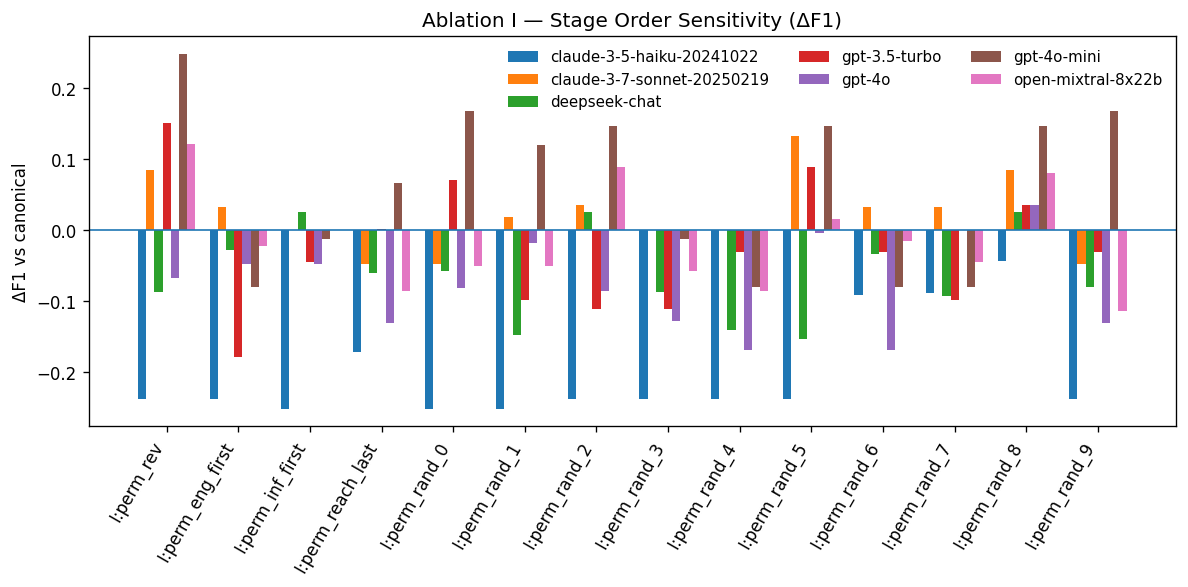

In [31]:
# Figure 1 — Ablation I: ΔF1 vs canonical (permutation sensitivity)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = abl1_with_delta.copy()
if df.empty:
    print("No Ablation I data.")
else:
    # Keep only permutations (exclude canonical itself)
    df = df[df["condition"] != "I:perm_0_canonical"].copy()
    models = df["model"].unique().tolist()
    conditions = df["condition"].unique().tolist()
    tbl = df.pivot_table(index="condition", columns="model", values="F1 ScoreΔ", aggfunc="mean").reindex(conditions)

    plt.figure(figsize=(10, 5), dpi=120)
    x = np.arange(len(tbl.index))
    width = 0.8 / max(1, len(models))

    for i, m in enumerate(models):
        vals = tbl[m].values if m in tbl.columns else np.zeros(len(x))
        plt.bar(x + i*width - (len(models)-1)*width/2, vals, width=width, label=m)

    plt.axhline(0, linewidth=1)
    plt.xticks(x, tbl.index, rotation=60, ha="right")
    plt.ylabel("ΔF1 vs canonical")
    plt.title("Ablation I — Stage Order Sensitivity (ΔF1)")
    plt.legend(frameon=False, fontsize=9, ncol=min(3, len(models)))
    plt.tight_layout()
    plt.show()

#### Figure 2. Context and Pipeline Isolation (Ablation II — Global F1)

This figure compares the **global F1 scores** achieved under different context and evidence configurations. Conditions range from *minimal context* (no evidence, short instruction) to *full guidance* (complete prompt and all evidence). Intermediate settings, such as "names_only_all" and "full_only_reach", isolate specific factors like stage naming or evidence restriction. The results reveal how **prompt richness and evidence inclusion** influence model performance and whether strong results depend on contextual scaffolding.

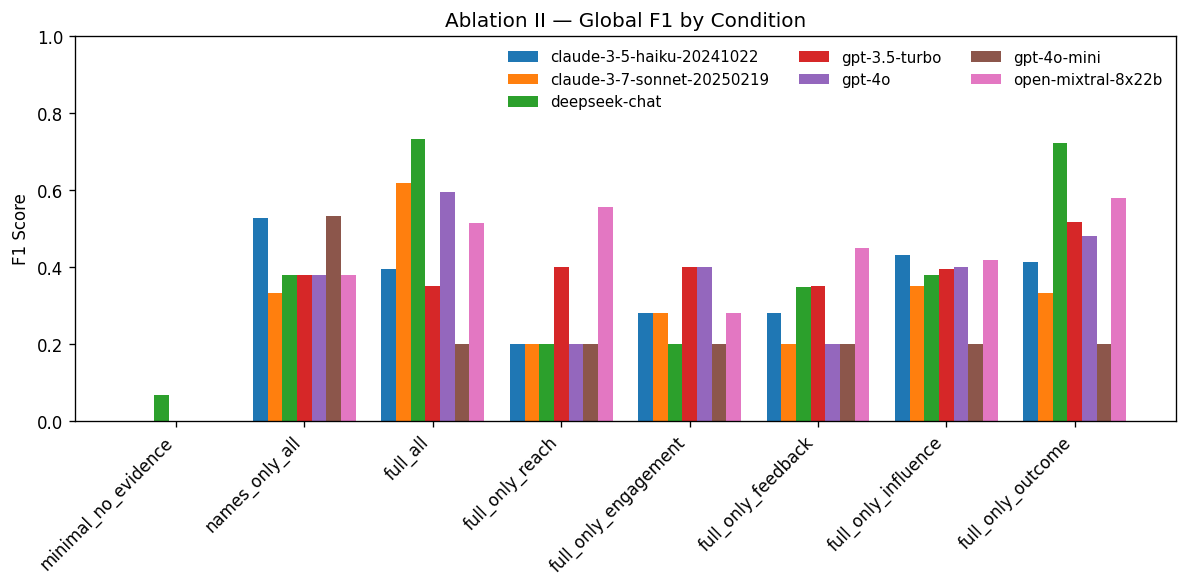

In [32]:
# Figure 2 — Ablation II: Global F1 per condition × model
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = abl2_summary.copy()
if df.empty:
    print("No Ablation II data.")
else:
    # Order conditions roughly from least to most guided
    cond_order = [
        "II:minimal_no_evidence",
        "II:names_only_all",
        "II:full_all",
        "II:full_only_reach",
        "II:full_only_engagement",
        "II:full_only_feedback",
        "II:full_only_influence",
        "II:full_only_outcome",
    ]
    cond_present = [c for c in cond_order if c in df["condition"].unique()]
    df = df[df["condition"].isin(cond_present)]
    models = df["model"].unique().tolist()

    tbl = df.pivot_table(index="condition", columns="model", values="F1 Score", aggfunc="mean").reindex(cond_present)

    plt.figure(figsize=(10, 5), dpi=120)
    x = np.arange(len(tbl.index))
    width = 0.8 / max(1, len(models))

    for i, m in enumerate(models):
        vals = tbl[m].values if m in tbl.columns else np.zeros(len(x))
        plt.bar(x + i*width - (len(models)-1)*width/2, vals, width=width, label=m)

    plt.xticks(x, [c.replace("II:", "") for c in tbl.index], rotation=45, ha="right")
    plt.ylabel("F1 Score")
    plt.title("Ablation II — Global F1 by Condition")
    plt.ylim(0, 1.0)
    plt.legend(frameon=False, fontsize=9, ncol=min(3, len(models)))
    plt.tight_layout()
    plt.show()

#### Figure 3. Deviation from Full-Guidance Baseline (Ablation II)

This figure presents **performance differences (Δ)** between each condition and the *full_all* baseline, across key metrics:  
- Accuracy, Precision, Recall, F1, and Hamming Loss.  
- Each bar quantifies how much model performance changes when removing or isolating context elements (e.g., evidence restriction or simplified prompt).  
- Smaller Δ values indicate **robustness to context removal**, while larger drops highlight **dependencies on guided prompting or full evidence**.

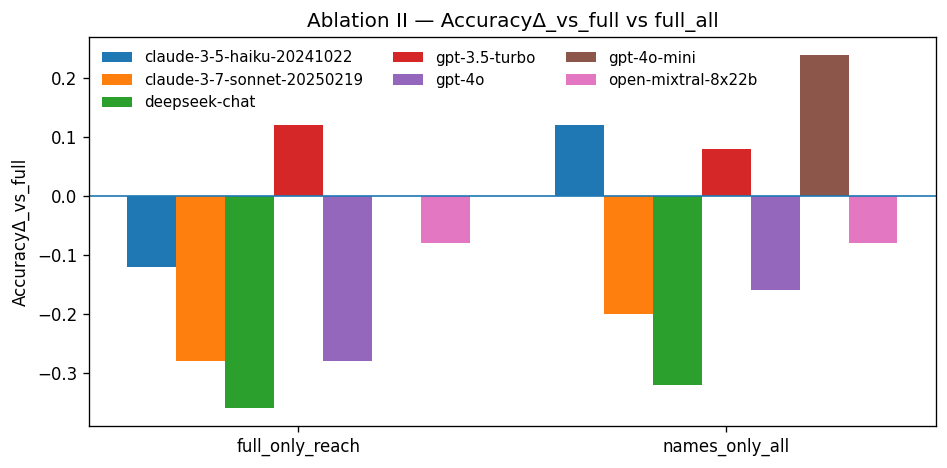

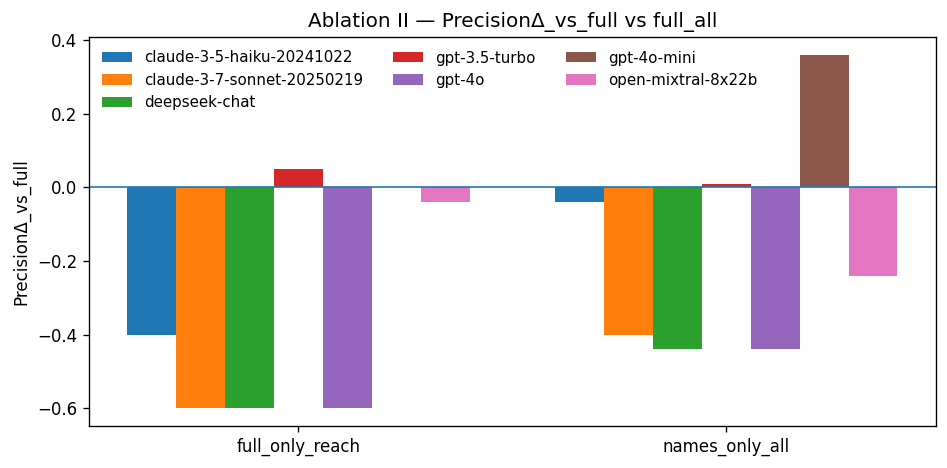

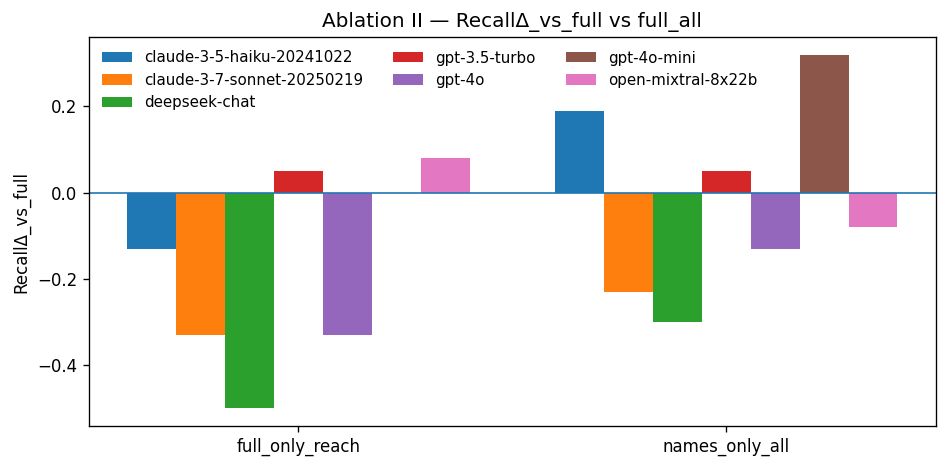

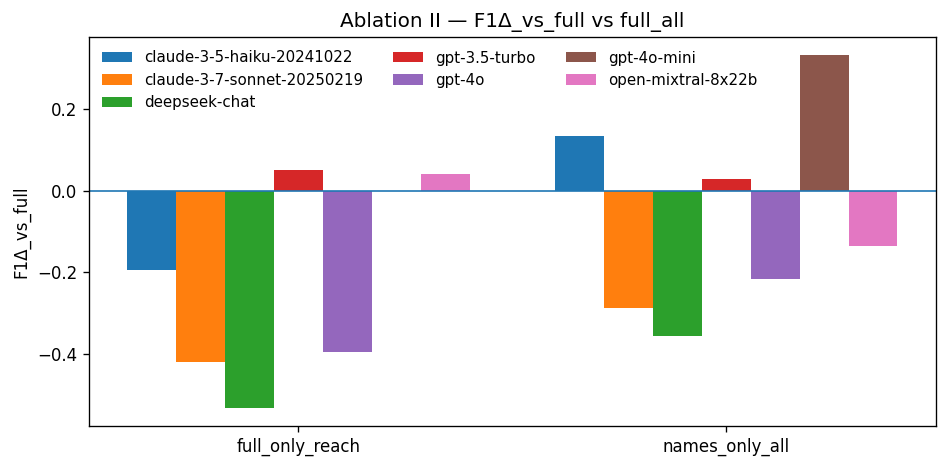

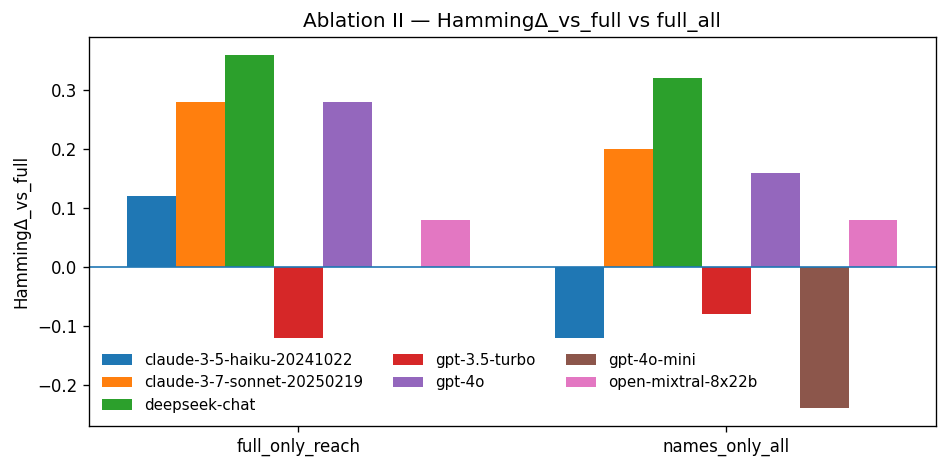

In [33]:
# Figure 3 — Ablation II: Δ vs full_all for key conditions (per model)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = abl2_with_delta.copy()
if df.empty:
    print("No Ablation II data.")
else:
    key = ["II:names_only_all", "II:full_only_reach"]
    df = df[df["condition"].isin(key)].copy()
    metrics = ["AccuracyΔ_vs_full", "PrecisionΔ_vs_full", "RecallΔ_vs_full", "F1 ScoreΔ_vs_full", "Hamming LossΔ_vs_full"]
    ren = {"F1 ScoreΔ_vs_full": "F1Δ_vs_full", "Hamming LossΔ_vs_full": "HammingΔ_vs_full"}
    df = df.rename(columns=ren)
    metrics = [ren.get(m, m) for m in metrics]

    for m in metrics:
        plt.figure(figsize=(8, 4), dpi=120)
        tbl = df.pivot_table(index="condition", columns="model", values=m, aggfunc="mean")
        x = np.arange(len(tbl.index))
        models = tbl.columns.tolist()
        width = 0.8 / max(1, len(models))
        for i, mod in enumerate(models):
            vals = tbl[mod].values
            plt.bar(x + i*width - (len(models)-1)*width/2, vals, width=width, label=mod)
        plt.axhline(0, linewidth=1)
        plt.xticks(x, [c.replace("II:", "") for c in tbl.index], rotation=0)
        plt.ylabel(m)
        plt.title(f"Ablation II — {m} vs full_all")
        plt.legend(frameon=False, fontsize=9, ncol=min(3, len(models)))
        plt.tight_layout()
        plt.show()

#### Figure 4. Per-Stage Behaviour across Ablations

These heatmaps visualise **per-stage F1 performance**, highlighting how well models predict each impact dimension under different settings.  
- Panel A (Ablation I) shows the mean F1 per stage across all stage-order permutations, reflecting stability of stage-level predictions.  
- Panel B (Ablation II) compares per-stage F1 under selected context conditions (full_all, full_only_reach, names_only_all).  

These views illustrate whether certain impact stages, such as *Reach* or *Outcome*, are more consistent or more sensitive to contextual cues in the prompt.

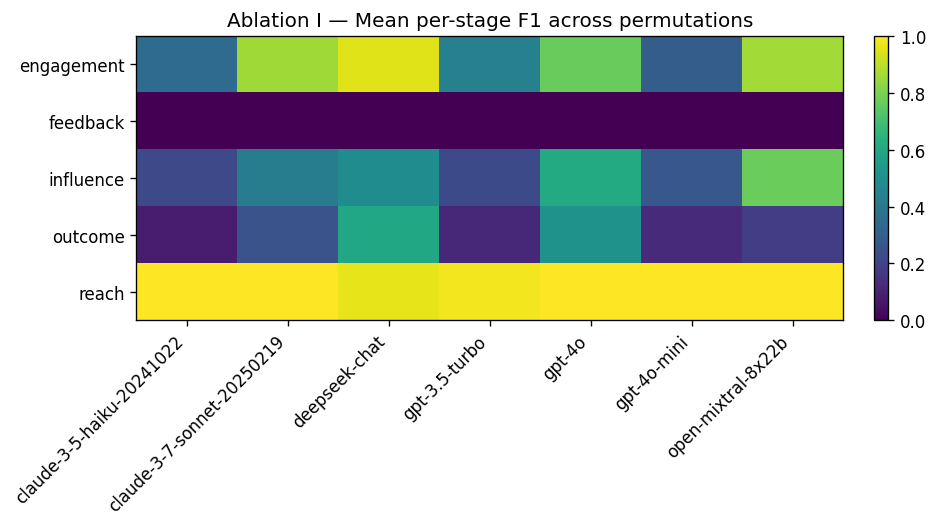

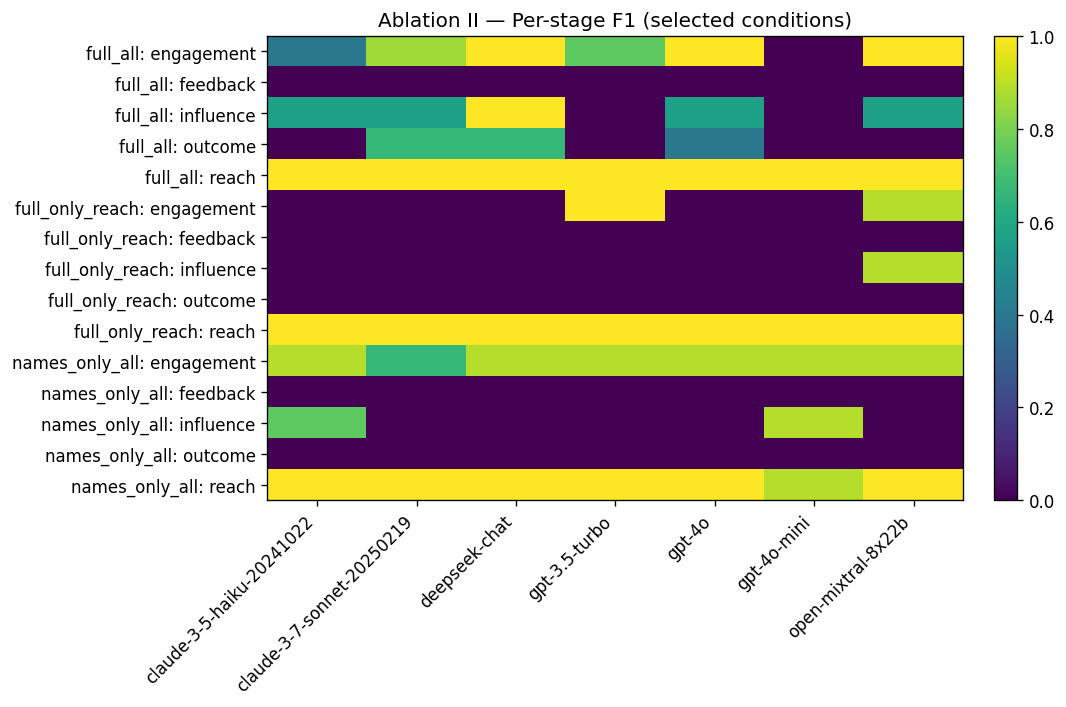

In [34]:
# Figure 4A — Ablation I: per-stage F1 (mean across permutations)
import matplotlib.pyplot as plt
import numpy as np

mat = abl1_stage_mean.copy() if 'abl1_stage_mean' in globals() else pd.DataFrame()
if mat.empty:
    print("No Ablation I per-stage data.")
else:
    plt.figure(figsize=(8, 4.5), dpi=120)
    im = plt.imshow(mat.values, aspect="auto", vmin=0, vmax=1)
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.yticks(range(len(mat.index)), mat.index)
    plt.xticks(range(len(mat.columns)), mat.columns, rotation=45, ha="right")
    plt.title("Ablation I — Mean per-stage F1 across permutations")
    plt.tight_layout()
    plt.show()

# Figure 4B — Ablation II: per-stage F1 (selected conditions stacked)
mat2 = abl2_stage_pivot.copy() if 'abl2_stage_pivot' in globals() else pd.DataFrame()
if mat2.empty:
    print("No Ablation II per-stage data.")
else:
    sel = [c for c in mat2.index.get_level_values(0).unique()
           if c in {"II:full_all","II:full_only_reach","II:names_only_all"}]
    mat2s = mat2.loc[mat2.index.get_level_values(0).isin(sel)]
    plt.figure(figsize=(9, 6), dpi=120)
    im = plt.imshow(mat2s.values, aspect="auto", vmin=0, vmax=1)
    plt.colorbar(im, fraction=0.046, pad=0.04)
    ylabs = [f"{cond.replace('II:','')}: {stage}" for cond, stage in mat2s.index]
    plt.yticks(range(len(ylabs)), ylabs)
    plt.xticks(range(len(mat2s.columns)), mat2s.columns, rotation=45, ha="right")
    plt.title("Ablation II — Per-stage F1 (selected conditions)")
    plt.tight_layout()
    plt.show()

## Summary of Ablation Results (Pilot Run, n = 200 topic pairs)

**Ablation I — Stage Order Shuffling**

- All models produced valid predictions under every permutation (empty rate = 0.0).  
- Mean ΔF1 values were small across models (typically within ±0.1), indicating **low sensitivity to stage order**.  
- Larger deviations appeared occasionally in smaller or highly instruction-tuned models (e.g., Claude-Haiku).  
- The canonical vs. reversed order comparison showed **no consistent degradation**, suggesting order independence.  
- Per-stage F1 means:
  - *Reach* = 1.0 for all models → perfectly stable.
  - *Feedback* = 0.0 for all models → no supporting data.
  - *Engagement* and *Influence* moderately stable across permutations.
  - *Outcome* variable, with some drops under shuffled orders.  
- These trends indicate that **models encode stage semantics independently of order**, with predictable differences linked to model scale and instruction tuning.

---

**Ablation II — Context and Pipeline Isolation**

- **Minimal prompt (no evidence):** all models produced empty outputs (empty rate = 1.0, F1 = 0.0).  
- **Names-only prompt:** all models recovered partial reasoning (F1 ≈ 0.33–0.53), showing prior knowledge of impact-stage semantics.  
- **Full prompt with evidence:** highest performance (F1 ≈ 0.59–0.73) across models.  
- **Single-stage evidence (full_only_reach):** consistent drop in performance (mean ΔF1 = −0.21; mean ΔHamming = +0.14), confirming reliance on multi-stage context.  
- GPT-3.5 and GPT-4o showed the smallest degradation under partial evidence, suggesting stronger generalisation to incomplete inputs.  
- Claude and DeepSeek were more context-sensitive, with larger ΔF1 losses under isolation.  
- Per-stage F1 patterns:
  - *Reach* = 1.0 across all conditions → highly stable anchor.
  - *Engagement* and *Influence* depend on contextual contrast to other stages.
  - *Outcome* partly preserved (F1 ≈ 0.4–0.7).
  - *Feedback* consistently absent (F1 = 0.0).  
- These results confirm that **contextual scaffolding and stage interrelations are essential** for accurate reasoning.

---

**Overall observations**

- Models are **robust to stage order** but **sensitive to contextual reduction**.  
- Performance collapses without structured evidence, indicating dependence on Flowmetrics’ information structure.  
- The *Reach* stage provides a stable baseline across all models and ablations.  
- The *Feedback* stage remains unsupported, reflecting data limitations rather than model incapacity.  
- Even in this mid-scale run (n = 200), qualitative trends are clear and consistent with expectations for the Flowmetrics framework.

## Discussion

**1. Did shuffling the presented order change sequence metrics in meaningful ways (signal vs. copy)?**  
- No. Across 10 permutations in Ablation I, all models maintained consistent stage-level performance (ΔF1 generally within ±0.1).  
- Empty prediction rates were 0.0 for every model and permutation, showing that reordering stages did not disrupt reasoning or induce copying behaviour.  
- The canonical and reversed orders produced nearly identical scores, indicating that models internalise stage semantics rather than merely echoing prompt order.  
- This stability suggests that LLMs are interpreting the impact stages as **conceptual categories**, not sequential cues.

---

**2. How sensitive are results to minimal context vs. added guidance?**  
- Highly sensitive. In Ablation II, removing all context (“minimal_no_evidence”) led to complete collapse (empty rate = 1.0).  
- When only stage names were provided, models recovered partial recall (F1 ≈ 0.33–0.53), reflecting limited background knowledge of impact-stage semantics.  
- Adding structured evidence and full guidance (“full_all”) restored strong performance (F1 ≈ 0.6–0.7).  
- This pattern confirms that contextual scaffolding, both in prompt structure and evidence content, is critical for reliable stage inference.

---

**3. Which pipeline components appear to contribute most to coherent stage predictions?**  
- The inclusion of **multi-stage evidence** contributes most to coherence.  
- When only single-stage evidence was supplied (“full_only_reach”), average F1 dropped by ≈ 0.21 and Hamming loss increased by ≈ 0.14 relative to “full_all”.  
- This demonstrates that LLMs rely on the **contrastive relationships between stages** to calibrate reasoning.  
- Reach remained perfectly predicted (F1 = 1.0) under all conditions, while higher-order stages (Engagement, Influence, Outcome) degraded without cross-stage context.  
- Therefore, **evidence diversity and inter-stage cues** are the key drivers of coherent predictions, more than stage order or token-level guidance.